In [1]:
pip install beautifulsoup4 --break-system-packages


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
pip install requests --break-system-packages


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
pip install lxml --break-system-packages


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd


In [5]:
# Step 1: Visit a website

url = 'http://quotes.toscrape.com/'
response = requests.get(url)

print(f' Status code: {response.status_code}')
print(f" Page length: {len(response.text)} characters")


 Status code: 200
 Page length: 11021 characters


In [13]:
# Step 2: Parse (understand) the HTML

soup= BeautifulSoup(response.text, 'lxml')

# Let's see what we got (first 500 characters)

print(soup.prettify()[:500])

<!DOCTYPE html>
<html lang="en">
 <head>
  <meta charset="utf-8"/>
  <title>
   Quotes to Scrape
  </title>
  <link href="/static/bootstrap.min.css" rel="stylesheet"/>
  <link href="/static/main.css" rel="stylesheet"/>
 </head>
 <body>
  <div class="container">
   <div class="row header-box">
    <div class="col-md-8">
     <h1>
      <a href="/" style="text-decoration: none">
       Quotes to Scrape
      </a>
     </h1>
    </div>
    <div class="col-md-4">
     <p>
      <a href="/login">
   


In [18]:
# Step 3: Find all quotes on the page

qoutes= soup.find_all('span', class_='text')
authors=soup.find_all('small', class_='author')

len(qoutes)

for i in range(len(qoutes)):
    print(f"\n {i+1} .{qoutes[i].text} - {authors[i].text}")



 1 .“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.” - Albert Einstein

 2 .“It is our choices, Harry, that show what we truly are, far more than our abilities.” - J.K. Rowling

 3 .“There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.” - Albert Einstein

 4 .“The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.” - Jane Austen

 5 .“Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.” - Marilyn Monroe

 6 .“Try not to become a man of success. Rather become a man of value.” - Albert Einstein

 7 .“It is better to be hated for what you are than to be loved for what you are not.” - André Gide

 8 .“I have not failed. I've just found 10,000 ways that won't work.” - Thomas A. Edison

 9 .“A woman is like a tea bag; you never know how strong i

In [22]:
# Step 4: Create a structured dataset

qoute_data = []

for i in range(len(qoutes)):
    
    qoute_data.append({
        'qoute':qoutes[i].text,
        'author':authors[i].text
    })

df=pd.DataFrame(qoute_data)

df.to_csv('scrapped_qoutes.csv', index=False)
print("Scrapping of data successful and saved")

Scrapping of data successful and saved


In [27]:
# Scraping multiple pages

all_qoutes=[]

base_url = 'http://quotes.toscrape.com/page/{}/'

for page_num in range(1,11):
    print(f'Scraping page {page_num}...')

    #url for the page
    url = base_url.format(page_num)

    #visit the page
    response=requests.get(url)
    soup=BeautifulSoup(response.text, 'lxml')

    #find qoutes and author from Page
    quotes= soup.find_all('span', class_="text")
    authors= soup.find_all('small', class_="author")
    tags= soup.find_all('div', class_="tags")

    #extract data

    for i in range(len(qoutes)):
        qoute_tags= [tag.text for tag in tags[i].find_all('a', class_='tag')]

        all_qoutes.append({
            'qoute': qoutes[i].text,
            'author': authors[i].text,
            'tags': ', '.join(qoute_tags)  #convert list to string
        })

df=pd.DataFrame(all_qoutes)

print(f" df {df.head(10)}")

df.to_csv('all_qoutes.csv', index=False)
        

Scraping page 1...
Scraping page 2...
Scraping page 3...
Scraping page 4...
Scraping page 5...
Scraping page 6...
Scraping page 7...
Scraping page 8...
Scraping page 9...
Scraping page 10...
 df                                                qoute             author  \
0  “The world as we have created it is a process ...    Albert Einstein   
1  “It is our choices, Harry, that show what we t...       J.K. Rowling   
2  “There are only two ways to live your life. On...    Albert Einstein   
3  “The person, be it gentleman or lady, who has ...        Jane Austen   
4  “Imperfection is beauty, madness is genius and...     Marilyn Monroe   
5  “Try not to become a man of success. Rather be...    Albert Einstein   
6  “It is better to be hated for what you are tha...         André Gide   
7  “I have not failed. I've just found 10,000 way...   Thomas A. Edison   
8  “A woman is like a tea bag; you never know how...  Eleanor Roosevelt   
9  “A day without sunshine is like, you know, nig...   

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_14228\1205997643.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=author_counts.values, y=author_counts.index, palette='rocket')


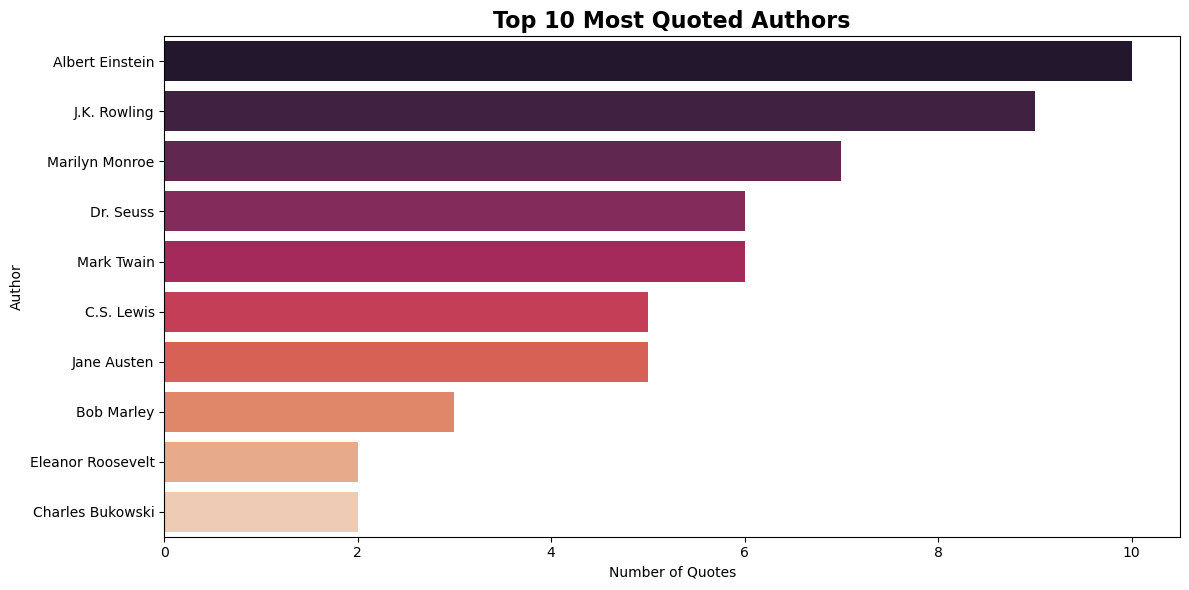

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Who has the most quotes?
author_counts = df['author'].value_counts().head(10) # .head(n) gives you top counts of authors 

plt.figure(figsize=(12, 6))
sns.barplot(x=author_counts.values, y=author_counts.index, palette='rocket')
plt.title('Top 10 Most Quoted Authors', fontsize=16, fontweight='bold')
plt.xlabel('Number of Quotes')
plt.ylabel('Author')
plt.tight_layout()
plt.show()